# 로지스틱 회귀(Logistic Regression)
입력 데이터가 특정 클래스에 속할 확률을 예측하는 분류 알고리즘

## 선형 회귀로는 분류가 안될까??

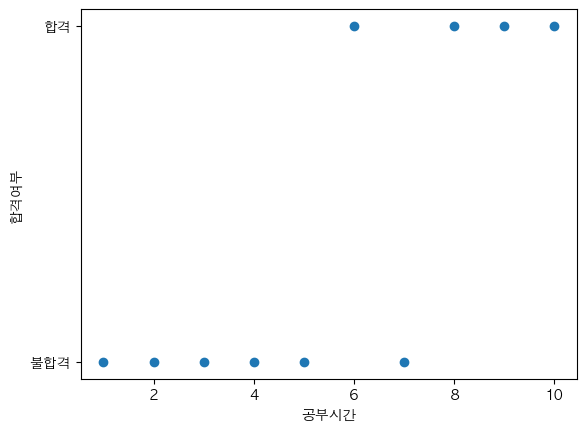

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

data = {
    "공부시간": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    "합격여부": [0, 0, 0, 0, 0, 1, 0, 1, 1, 1]
}

df = pd.DataFrame(data)

plt.scatter(df["공부시간"], df["합격여부"])
plt.xlabel("공부시간")
plt.ylabel("합격여부")
plt.yticks([0, 1], ["불합격", "합격"])
plt.show()

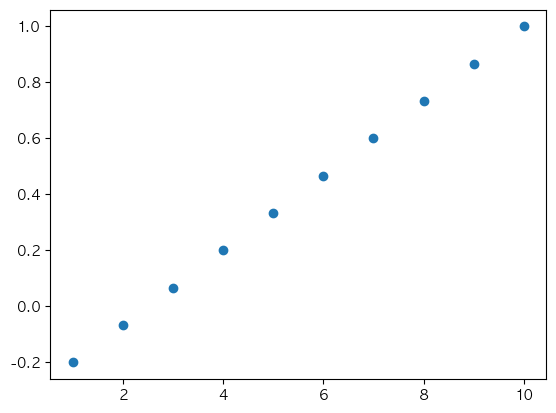

In [ ]:
# 하지만 선형 회귀로 분류하게 되면 값의 범위도 그렇고 잘 예측되지 않는다.

from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(df[["공부시간"]], df["합격여부"])

y_pred = model.predict(df[["공부시간"]])

plt.scatter(df["공부시간"], y_pred)

## 예측값이 확률이 된다면 좋지 않을까?
하지만 확률의 값은 0-1로 제한되어 있어 $\hat{y} = wx + b$의 값의 범위와 달라진다.

## 오즈
어떤 사건이 일어날 확률과 일어나지 않을 확률의 비율을 오즈라고 한다.

확률의 범위는 0-1인 반면 오즈의 범위는 0-inf까지다.

하지만 아직 음수 부분을 커버하지 못한다는 문제가 있다.

$$Odds = \frac{p}{1-p}$$

/var/folders/x2/_ysblkzj38n3zryb8y5w9kz40000gn/T/ipykernel_36374/2069677683.py:2: RuntimeWarning: divide by zero encountered in divide
  y = X / (1 - X)


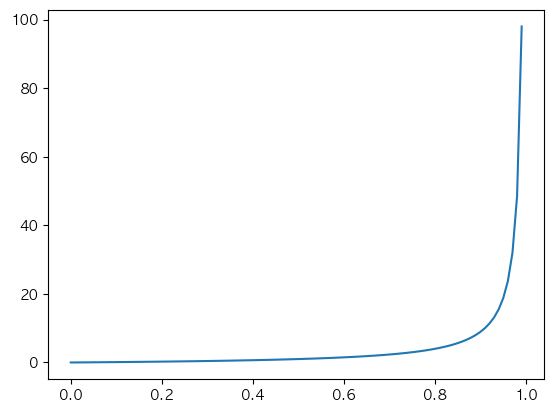

In [17]:
X = np.linspace(0, 1, 100)
y = X / (1 - X)

plt.plot(X, y)

## 로짓
그럼 오즈에 로그를 씌운다면 모든 범위를 커버할 수 있지 않을까?

$$Logits = \log\frac{p}{1-p}$$

/var/folders/x2/_ysblkzj38n3zryb8y5w9kz40000gn/T/ipykernel_36374/1653899704.py:2: RuntimeWarning: divide by zero encountered in divide
  y = np.log(X / (1 - X))
/var/folders/x2/_ysblkzj38n3zryb8y5w9kz40000gn/T/ipykernel_36374/1653899704.py:2: RuntimeWarning: divide by zero encountered in log
  y = np.log(X / (1 - X))


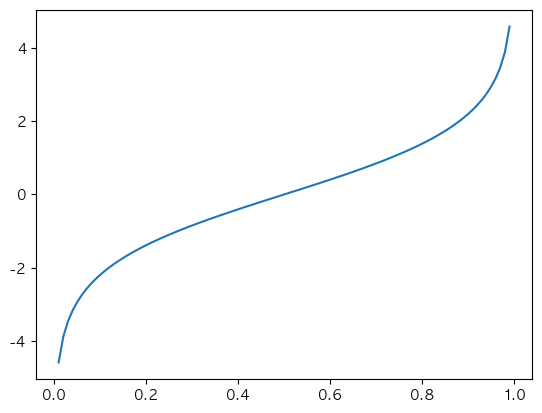

In [16]:
X = np.linspace(0, 1, 100)
y = np.log(X / (1 - X))

plt.plot(X, y)

## 그렇다면 로지스틱 회귀의 식은 다음과 같이 된다.
$$ w_{0} + w_{1}x_{1} + w_{2}x_{2} + \cdots + w_{k}x_{k} = \log\frac{p}{1-p}$$

## 만약 선형 회귀 방정식의 결과가 로짓으로 나온다면 로짓을 다시 확률로 변환해야 되는데?
선형 회귀 방정식을 z라고 하면 다음과 같다.

양변에 $e$를 씌우면 $e^z = \frac{p}{1-p}$

양변에 $(1-p)$를 곱하면 $e^z - p \cdot e^z = p$

$p$로 정리하면 $e^z = p(1 + e^z)$ → $p = \frac{e^z}{1 + e^z}$

분자분모를 $e^z$로 나누면 $p = \frac{1}{1 + e^{-z}}$

우리는 이를 시그모이드 함수라고 한다.
$$ Sigmoid = \frac{1}{1+e^{-z}}$$

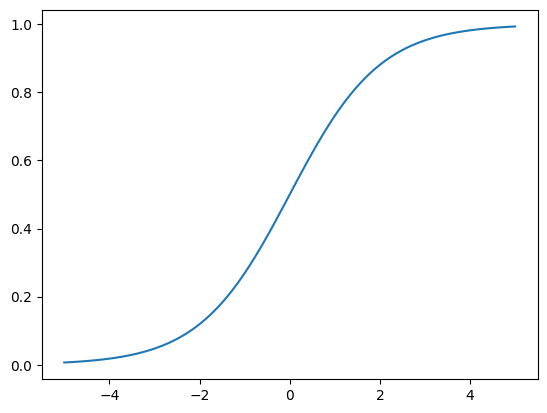

In [ ]:
X = np.linspace(-5, 5, 100)
y = 1 / (1 + np.exp(-X))

plt.plot(X, y)

## 손실함수는 무엇을 사용할까?
예측이 맞을 확률을 식으로 표현하면:

실제 y=1일 때: 맞을 확률 = $\hat{y}$ (예측 확률이 높을수록 좋음)
실제 y=0일 때: 맞을 확률 = $1 - \hat{y}$ (예측 확률이 낮을수록 좋음)

$P = \hat{y}^y \cdot (1-\hat{y})^{1-y}$


전체 데이터에 대해 곱하면 (우도):

$L = \prod_{i=1}^{n} \hat{y}_i^{y_i} \cdot (1-\hat{y}_i)^{1-y_i}$

곱셈은 다루기 어려우니 로그를 씌우면:

$\log L = \sum_{i=1}^{n} [y\log\hat{y} + (1-y)\log(1-\hat{y})]$

최대화 → 최소화로 바꾸기 위해 마이너스 붙이면:

$BCE = -\sum_{i=1}^{n} [y\log\hat{y} + (1-y)\log(1-\hat{y})]$

$$ \text{Cross-Entropy} = -\sum_{i=1}^{n} [y\log\hat{y} + (1-y)\log(1-\hat{y})]$$

## 로지스틱 회귀 구현하기

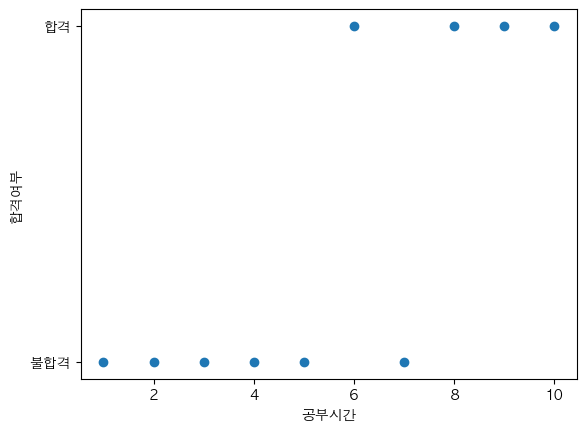

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

data = {
    "공부시간": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    "합격여부": [0, 0, 0, 0, 0, 1, 0, 1, 1, 1]
}

df = pd.DataFrame(data)

plt.scatter(df["공부시간"], df["합격여부"])
plt.xlabel("공부시간")
plt.ylabel("합격여부")
plt.yticks([0, 1], ["불합격", "합격"])
plt.show()

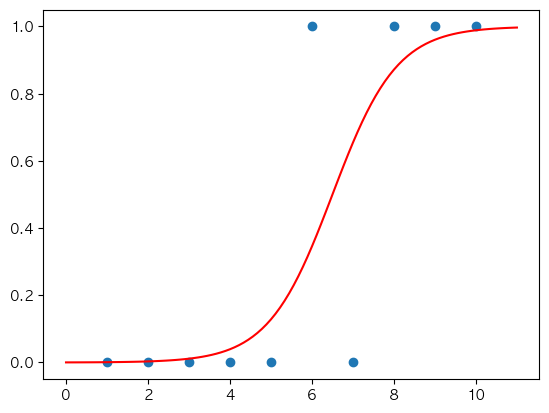

In [ ]:
# 시그모이드 함수 정의
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# 로지스틱 회귀 함수 정의
def logisticRegression(X, y, epochs, lr):
    w, b = 0.0, 0.0
    n = len(X)
    loss_history = []

    for epoch in range(epochs):
        z = w * X + b
        pred = sigmoid(z)

        dw = (1 / n) * np.sum((pred - y) * X)
        db = (1 / n) * np.sum(pred - y)

        w -= lr * dw
        b -= lr * db

        loss = -(1 / n) * np.sum(y * np.log(pred) + (1-y) * np.log(1 - pred))
        loss_history.append(loss)

    return w, b, loss_history

w, b, loss_history = logisticRegression(np.array(df["공부시간"]), np.array(df["합격여부"]), epochs=10000, lr=0.1)

X = np.linspace(0, 11, 100)
z = w * X + b
y_pred = sigmoid(z)

plt.scatter(df["공부시간"], df["합격여부"])
plt.plot(X, y_pred, 'red')
plt.show()

## Sklearn으로 로지스틱 회귀 구현

### 라이브러리 임포트

In [ ]:
from sklearn.datasets import load_iris # 데이터셋 가져오기
from sklearn.model_selection import train_test_split # 학습 데이터, 테스트 데이터 분리

from sklearn.linear_model import LogisticRegression # 로지스틱 회귀 모델 가져오기
from sklearn.metrics import accuracy_score # 정확도

### 데이터 불러오기

In [ ]:
data = load_iris()
data.keys() # 데이터의 key값을 가져와서 어디에 데이터, 타겟이 있는지 확인

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [ ]:
# feature와 target 데이터 분리
X = data.data
y = data.target

# 학습 데이터, 테스트 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size= 0.7)

print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(105, 4)
(105,)
(45, 4)
(45,)


In [ ]:
# 모델 불러오기
model = LogisticRegression()

# 모델 학습
model.fit(X_train, y_train)

# 예측
y_pred = model.predict(X_test)

# 정확도 출력
print(f"정확도는 {accuracy_score(y_test, y_pred) * 100}%")

정확도는 100.0%
